# Análise dos Modelos — Zé Praga 🌱
**Diagnóstico de doenças foliares de soja · TCC**

Comparação das 3 arquiteturas treinadas no dataset **ASDID** (ResNet-50, EfficientNet-B4, ViT-B/16)
e do **ensemble** (média das probabilidades), avaliados no split de **teste** (n=1221, imagens não
vistas no treino).

> Notebook de análise — usa os modelos já treinados (ONNX) e as métricas salvas. Não re-treina.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
from PIL import Image

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
METRICS = ROOT / 'artifacts' / 'metrics'
FIGURES = ROOT / 'artifacts' / 'figures'
ONNX = ROOT / 'artifacts' / 'onnx'

NAMES = {'resnet50': 'ResNet-50', 'efficientnet_b4': 'EfficientNet-B4', 'vit_b16': 'ViT-B/16', 'ensemble': 'Ensemble'}
CLASS_PT = {'cercosporiose': 'Cercosporiose', 'ferrugem-asiatica': 'Ferrugem Asiática',
            'mancha-alvo': 'Mancha-Alvo', 'mancha-olho-de-ra': 'Mancha Olho-de-rã',
            'mildio': 'Míldio', 'saudavel': 'Saudável'}
def load(m): return json.loads((METRICS / f'metrics_{m}.json').read_text(encoding='utf-8'))
print('ROOT =', ROOT)

ROOT = C:\Users\FelipeCarillo\tcc\tcc-ze-praga-model-playground


## 1. Dataset ASDID — distribuição das classes

Total: 8130 imagens | train 5690 · val 1219 · test 1221 (~70/15/15)


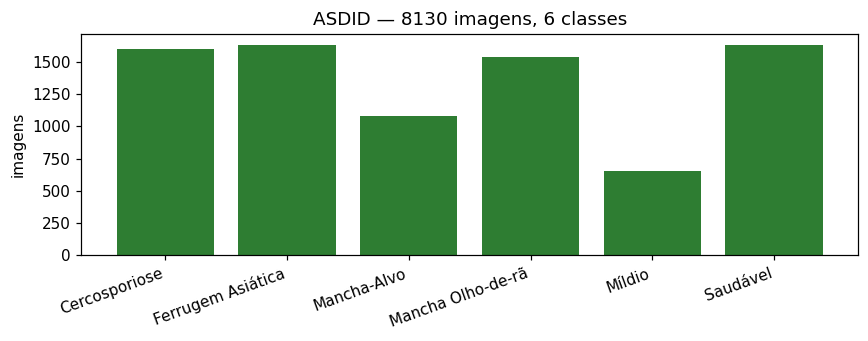

In [2]:
import csv
splits = {}
for s in ['train', 'val', 'test']:
    rows = list(csv.DictReader(open(ROOT / 'data' / 'processed' / f'{s}.csv', encoding='utf-8')))
    splits[s] = rows
counts = {}
for r in splits['train'] + splits['val'] + splits['test']:
    counts[r['label']] = counts.get(r['label'], 0) + 1
order = ['cercosporiose','ferrugem-asiatica','mancha-alvo','mancha-olho-de-ra','mildio','saudavel']
total = sum(counts.values())
print(f"Total: {total} imagens | train {len(splits['train'])} · val {len(splits['val'])} · test {len(splits['test'])} (~70/15/15)")
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar([CLASS_PT[c] for c in order], [counts[c] for c in order], color='#2E7D32')
ax.set_ylabel('imagens'); ax.set_title(f'ASDID — {total} imagens, 6 classes')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 2. Comparação das arquiteturas (test-set)

In [3]:
rows = []
for m in ['ensemble', 'efficientnet_b4', 'vit_b16', 'resnet50']:
    d = load(m)
    rows.append({'Modelo': NAMES[m], 'Accuracy': d['accuracy'], 'F1 macro': d['f1_macro'],
                 'Precision': d.get('precision_macro'), 'Recall': d.get('recall_macro')})
df = pd.DataFrame(rows).set_index('Modelo')
display((df * 100).round(2).astype(str) + ' %')

,Accuracy,F1 macro,Precision,Recall
Modelo,,,,
Ensemble,99.1 %,99.17 %,nan %,nan %
EfficientNet-B4,98.77 %,98.82 %,98.96 %,98.69 %
ViT-B/16,98.03 %,98.06 %,98.35 %,97.8 %
ResNet-50,95.99 %,96.13 %,96.3 %,96.0 %


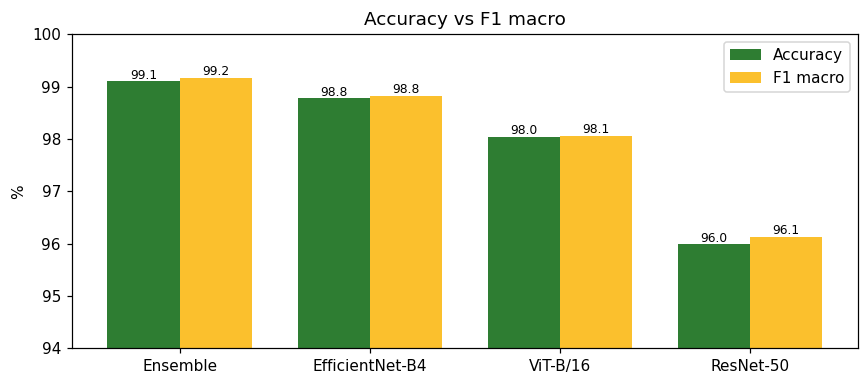

Ensemble vence todos os modelos individuais.


In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(df)); w = 0.38
ax.bar(x - w/2, df['Accuracy']*100, w, label='Accuracy', color='#2E7D32')
ax.bar(x + w/2, df['F1 macro']*100, w, label='F1 macro', color='#FBC02D')
ax.set_xticks(x); ax.set_xticklabels(df.index); ax.set_ylim(94, 100)
ax.set_ylabel('%'); ax.set_title('Accuracy vs F1 macro'); ax.legend()
for i, (a, f) in enumerate(zip(df['Accuracy'], df['F1 macro'])):
    ax.text(i - w/2, a*100 + 0.05, f'{a*100:.1f}', ha='center', fontsize=8)
    ax.text(i + w/2, f*100 + 0.05, f'{f*100:.1f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print('Ensemble vence todos os modelos individuais.')

## 3. F1-score por classe (modelos individuais)

,ResNet-50,EfficientNet-B4,ViT-B/16
Cercosporiose,97.0,99.6,99.0
Ferrugem Asiática,97.8,99.6,98.4
Mancha-Alvo,97.8,98.4,96.8
Mancha Olho-de-rã,93.8,97.9,97.6
Míldio,96.4,99.5,99.0
Saudável,93.9,98.0,97.6


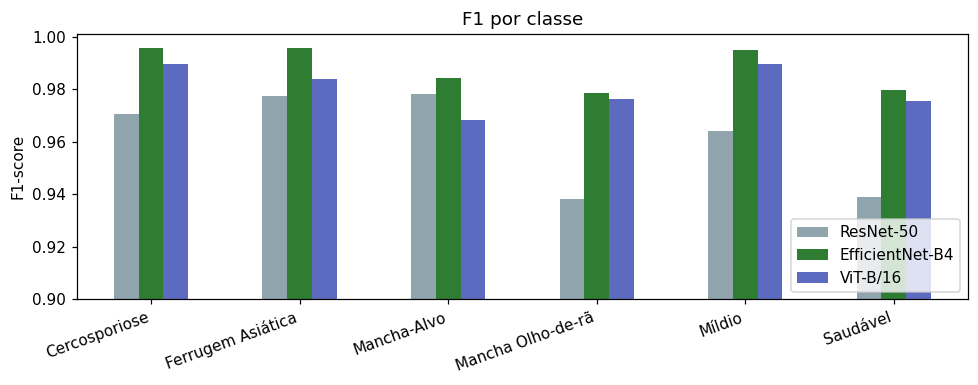

In [5]:
pc_rows = {}
for m in ['resnet50', 'efficientnet_b4', 'vit_b16']:
    pc = load(m)['per_class']
    pc_rows[NAMES[m]] = {CLASS_PT[k]: v['f1-score'] for k, v in pc.items() if k in CLASS_PT}
pcdf = pd.DataFrame(pc_rows)
display((pcdf * 100).round(1))
ax = pcdf.plot(kind='bar', figsize=(9, 3.6), color=['#90A4AE', '#2E7D32', '#5C6BC0'])
ax.set_ylim(0.90, 1.001); ax.set_ylabel('F1-score'); ax.set_title('F1 por classe')
plt.xticks(rotation=20, ha='right'); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 4. Matrizes de confusão

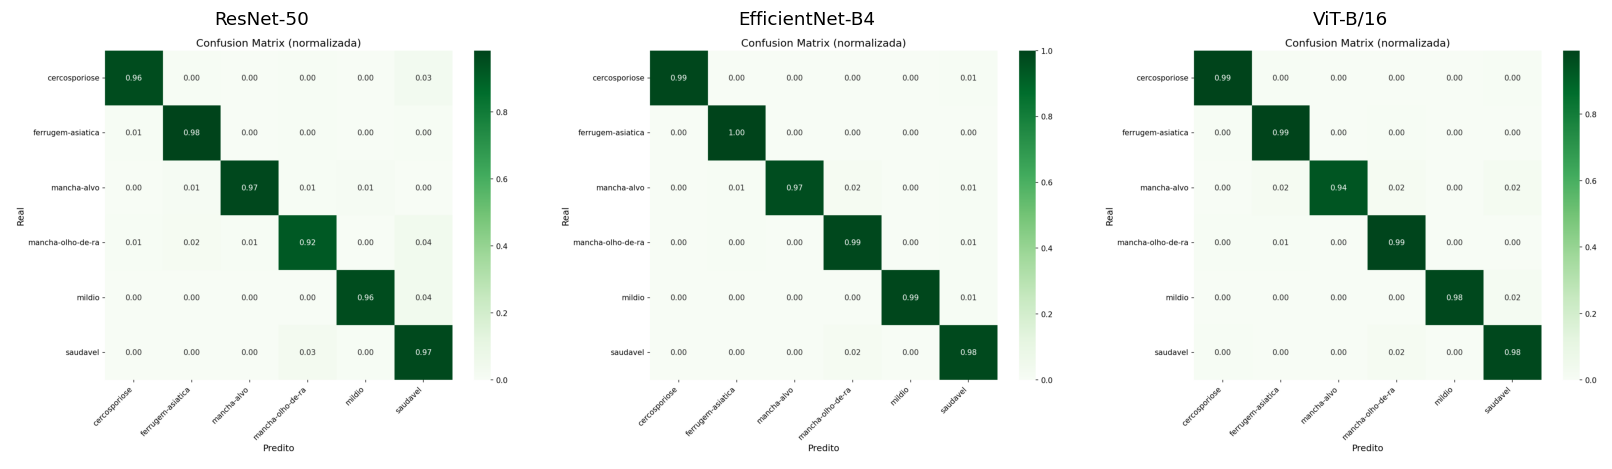

In [6]:
# Matrizes de confusao por modelo (figuras geradas no treino)
imgs = [(NAMES[m], FIGURES / f'confusion_{m}.png') for m in ['resnet50', 'efficientnet_b4', 'vit_b16']]
imgs = [(n, p) for n, p in imgs if p.exists()]
if imgs:
    fig, axes = plt.subplots(1, len(imgs), figsize=(5*len(imgs), 4.2))
    if len(imgs) == 1: axes = [axes]
    for ax, (n, p) in zip(axes, imgs):
        ax.imshow(Image.open(p)); ax.axis('off'); ax.set_title(n)
    plt.tight_layout(); plt.show()
else:
    print('Figuras de confusao nao encontradas.')

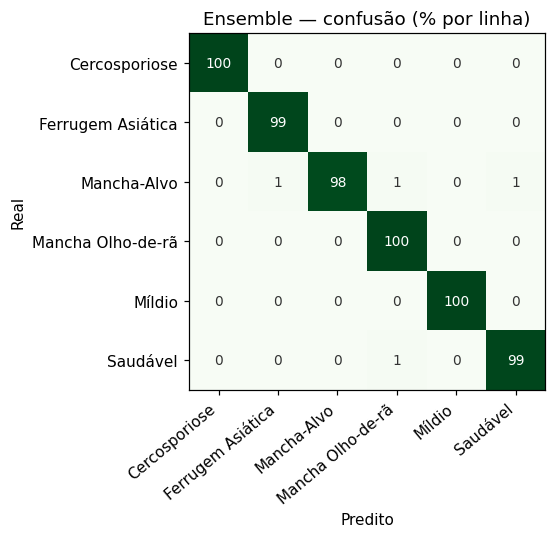

In [7]:
# Matriz de confusao do ENSEMBLE (test-set, % por linha)
ens = load('ensemble')['confusion_matrix_pct']
labels = [CLASS_PT[c] for c in ens['labels']]
cm = np.array(ens['rows_true_cols_pred'])
fig, ax = plt.subplots(figsize=(5.6, 5))
im = ax.imshow(cm, cmap='Greens', vmin=0, vmax=100)
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(labels, rotation=40, ha='right'); ax.set_yticklabels(labels)
ax.set_xlabel('Predito'); ax.set_ylabel('Real'); ax.set_title('Ensemble — confusão (% por linha)')
for i in range(6):
    for j in range(6):
        v = cm[i, j]
        ax.text(j, i, f'{v}', ha='center', va='center', color='white' if v > 50 else '#333', fontsize=9)
plt.tight_layout(); plt.show()

## 5. Predições ao vivo (uma imagem de teste por classe)

In [8]:
MEAN = np.array([0.485, 0.456, 0.406], np.float32); STD = np.array([0.229, 0.224, 0.225], np.float32)
SIZES = {'resnet50': 224, 'efficientnet_b4': 380, 'vit_b16': 224}
LABELS = json.loads((ROOT.parent / 'tcc-ze-praga-backend' / 'models' / 'soja_efficientnet_b4.labels.json').read_text())
sess = {m: ort.InferenceSession(str(ONNX / f'{m}.onnx'), providers=['CPUExecutionProvider']) for m in SIZES}
io_ = {m: (s.get_inputs()[0].name, s.get_outputs()[0].name) for m, s in sess.items()}
def probs(m, path):
    s = SIZES[m]
    img = Image.open(path).convert('RGB').resize((s, s), Image.Resampling.BILINEAR)
    x = (np.asarray(img, np.float32)/255.0 - MEAN)/STD
    x = np.ascontiguousarray(np.transpose(x, (2,0,1))[None], np.float32)
    inn, out = io_[m]
    lg = sess[m].run([out], {inn: x})[0][0].astype(np.float64)
    e = np.exp(lg - lg.max()); return e/e.sum()
# 1 imagem por classe (primeira ocorrencia no test set)
samples = {}
for r in splits['test']:
    if r['label'] not in samples:
        samples[r['label']] = r['filepath']
samples = {c: samples[c] for c in order if c in samples}
print(f'{len(samples)} amostras (1 por classe)')

6 amostras (1 por classe)


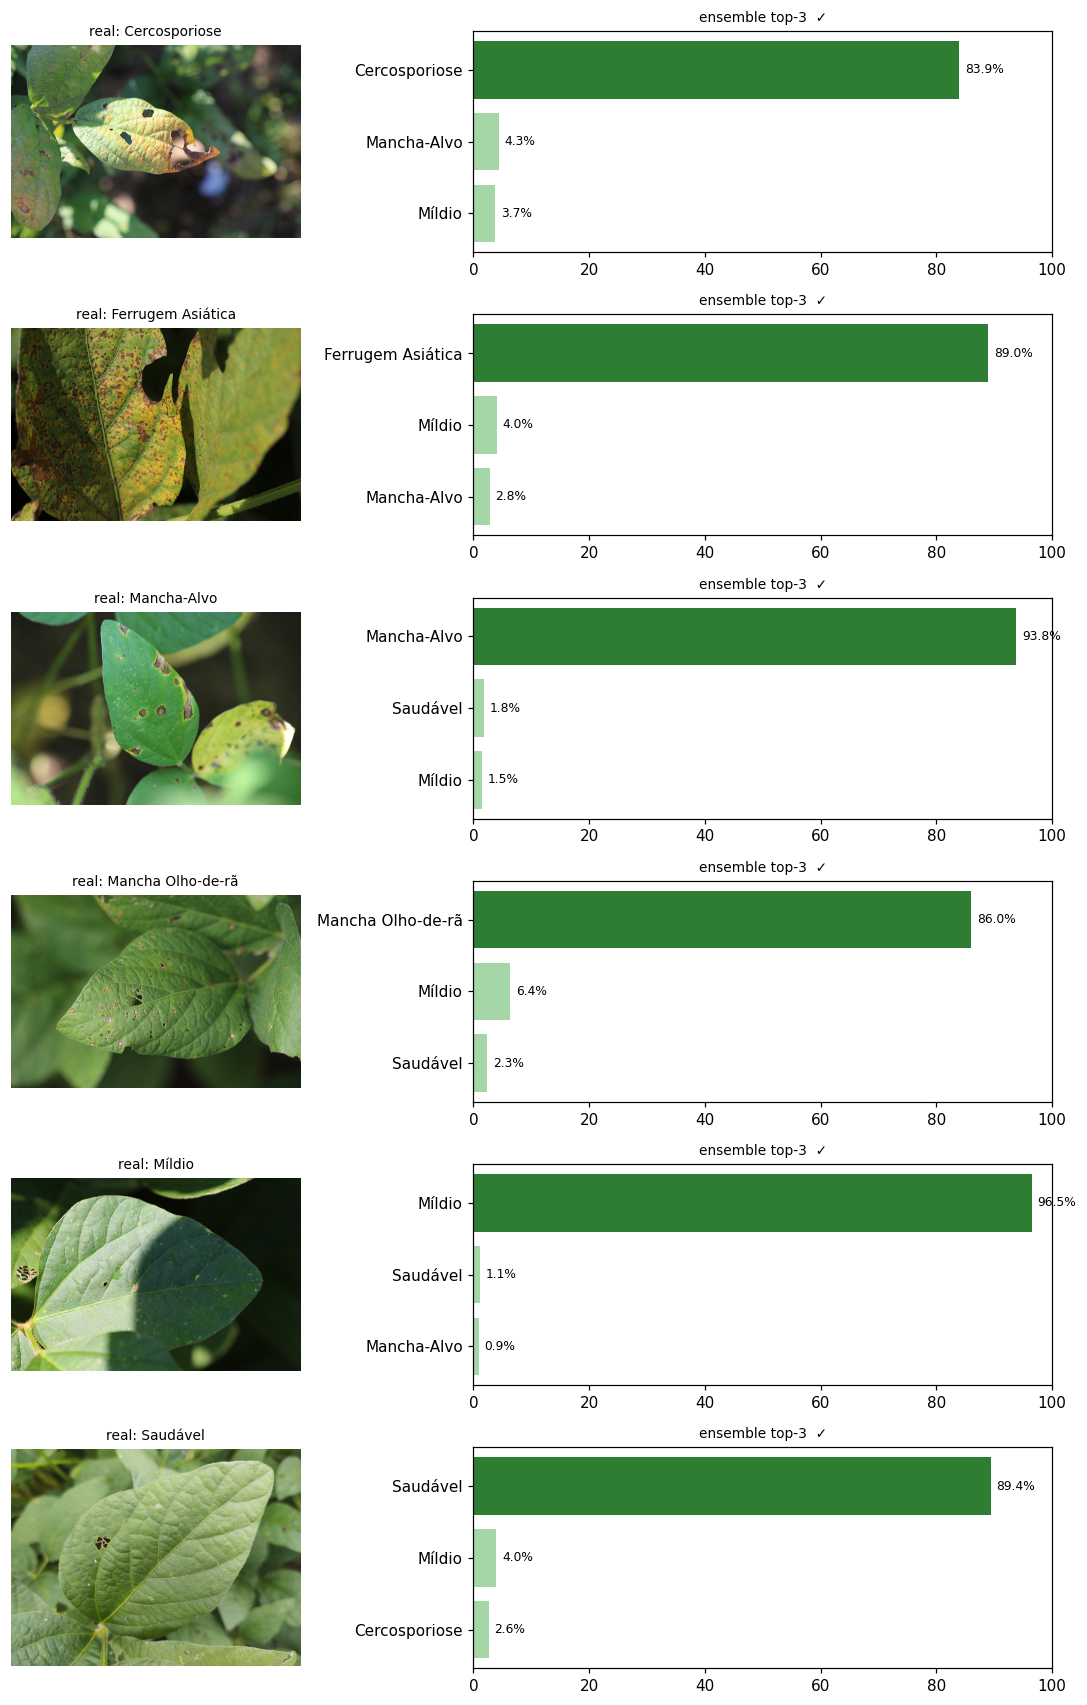

In [9]:
fig, axes = plt.subplots(len(samples), 2, figsize=(10, 2.6*len(samples)),
                         gridspec_kw={'width_ratios': [1, 2]})
for ax_row, (true, path) in zip(axes, samples.items()):
    ax_img, ax_bar = ax_row
    ax_img.imshow(Image.open(path).convert('RGB')); ax_img.axis('off')
    ax_img.set_title(f'real: {CLASS_PT[true]}', fontsize=9)
    pv = {m: probs(m, path) for m in SIZES}
    ens_v = sum(pv.values())/len(pv)
    top = np.argsort(ens_v)[::-1][:3]
    names = [CLASS_PT[LABELS[i]] for i in top][::-1]
    vals = [ens_v[i]*100 for i in top][::-1]
    colors = ['#2E7D32' if LABELS[top[0]] == true else '#C62828'] + ['#A5D6A7', '#A5D6A7']
    ax_bar.barh(names, vals, color=colors[::-1])
    ax_bar.set_xlim(0, 100)
    for k, v in enumerate(vals): ax_bar.text(v+1, k, f'{v:.1f}%', va='center', fontsize=8)
    pred_ok = '✓' if LABELS[top[0]] == true else '✗'
    ax_bar.set_title(f'ensemble top-3  {pred_ok}', fontsize=9)
plt.tight_layout(); plt.show()

## 6. Conclusão

- **Ensemble** (média das 3 redes) é o melhor: **99,1% de acurácia / 99,17% F1 macro** no test-set —
  servido por padrão no app.
- Entre os individuais, **EfficientNet-B4** lidera (98,8%), seguido de ViT-B/16 (98,0%) e ResNet-50 (96,0%).
- A confusão residual concentra-se em **Mancha-Alvo** em estágio inicial; as demais classes ficam ≥98%.
- Todas as classes têm suporte de teste balanceado (98–246 imagens), reforçando a robustez das métricas.